In [1]:
import numpy as np
import cv2
import requests
from io import BytesIO

import matplotlib.pyplot as plt
from PIL import Image

### 1.1 Histograma

In [2]:
def histograma_pixel_a_pixel(imagem):
    """
    Calcula e plota o histograma percorrendo a imagem pixel a pixel.
    Espera uma imagem em tons de cinza (uint8).
    """
    histograma = np.zeros(256, dtype=int)

    for px in imagem.ravel():
        histograma[px] += 1

    plt.bar(range(256), histograma)
    plt.xlabel("Nível de cinza")
    plt.ylabel("Quantidade de pixels")
    plt.title("Histograma da imagem")
    plt.show()


def histograma_matplotlib(imagem, titulo="Histograma da imagem"):
    """
    Plota o histograma usando a função pronta hist() do Matplotlib.
    Espera uma imagem em tons de cinza (uint8).
    """
    plt.hist(imagem.ravel(), bins=256, range=(0, 256), color="gray")
    plt.xlabel("Nível de cinza")
    plt.ylabel("Quantidade de pixels")
    plt.title(titulo)
    plt.show()

### 1.2 Limiarização

In [3]:
def limiarizacao_pixel_a_pixel(imagem, limiar, tipo="superior"):
    """
    Aplica limiarização binária percorrendo a imagem pixel a pixel.

    tipo="superior":
        pixels >= limiar recebem 255
        pixels < limiar recebem 0

    tipo="inferior":
        pixels <= limiar recebem 255
        pixels > limiar recebem 0
    """
    resultado = np.zeros_like(imagem)

    for i in range(imagem.shape[0]):
        for j in range(imagem.shape[1]):

            if tipo == "superior":
                if imagem[i, j] >= limiar:
                    resultado[i, j] = 255

            elif tipo == "inferior":
                if imagem[i, j] <= limiar:
                    resultado[i, j] = 255

    return resultado


def limiarizacao_numpy(imagem, limiar, tipo="superior"):
    """
    Aplica limiarização binária usando operações vetorizadas do NumPy.
    """
    if tipo == "superior":
        return np.where(imagem >= limiar, 255, 0).astype(np.uint8)

    elif tipo == "inferior":
        return np.where(imagem <= limiar, 255, 0).astype(np.uint8)

    else:
        raise ValueError("O tipo deve ser 'superior' ou 'inferior'.")

### 1.3 Expansão de contraste

In [4]:
def expansao_contraste_pixel_a_pixel(imagem):
    """
    Aplica expansão de contraste percorrendo a imagem pixel a pixel.

    O menor valor da imagem é mapeado para 0
    e o maior valor é mapeado para 255.
    """
    L = imagem.min()
    H = imagem.max()

    if H == L:
        return imagem.copy()

    resultado = np.zeros_like(imagem)

    for i in range(imagem.shape[0]):
        for j in range(imagem.shape[1]):
            resultado[i, j] = (
                (imagem[i, j] - L) * 255 / (H - L)
            )

    return resultado.astype(np.uint8)


def expansao_contraste_numpy(imagem):
    """
    Aplica expansão de contraste usando operações vetorizadas do NumPy.
    """
    L = imagem.min()
    H = imagem.max()

    if H == L:
        return imagem.copy()

    resultado = (imagem.astype(float) - L) * 255 / (H - L)

    return resultado.astype(np.uint8)

### 1.4 Equalização de histograma

In [5]:
def equalizacao_histograma_manual(imagem):
    """
    Equaliza o histograma manualmente.

    Espera uma imagem em tons de cinza (uint8).
    """
    histograma = np.zeros(256, dtype=int)

    # Calcula o histograma
    for i in range(imagem.shape[0]):
        for j in range(imagem.shape[1]):
            nivel = imagem[i, j]
            histograma[nivel] += 1

    # Calcula a distribuição acumulada (CDF)
    cdf = np.cumsum(histograma)

    # Normaliza a CDF para o intervalo [0, 255]
    cdf_normalizada = 255 * cdf / cdf[-1]

    resultado = np.zeros_like(imagem)

    # Substitui cada pixel pelo novo nível de cinza
    for i in range(imagem.shape[0]):
        for j in range(imagem.shape[1]):
            resultado[i, j] = cdf_normalizada[imagem[i, j]]

    return resultado.astype(np.uint8)


def equalizacao_histograma_opencv(imagem):
    """
    Equaliza o histograma usando a função pronta do OpenCV.
    """
    return cv2.equalizeHist(imagem)

### 1.5 Correção gamma

In [6]:
def correcao_gamma_pixel_a_pixel(imagem, gamma):
    """
    Aplica correção de gamma percorrendo a imagem pixel a pixel.

    gamma < 1  -> clareia a imagem
    gamma > 1  -> escurece a imagem
    gamma = 1  -> mantém a imagem
    """
    if gamma <= 0:
        raise ValueError("O valor de gamma deve ser maior que zero.")

    resultado = np.zeros_like(imagem)

    for i in range(imagem.shape[0]):
        for j in range(imagem.shape[1]):
            r = imagem[i, j] / 255.0
            resultado[i, j] = 255 * (r ** gamma)

    return resultado.astype(np.uint8)


def correcao_gamma_numpy(imagem, gamma):
    """
    Aplica correção de gamma usando operações vetorizadas do NumPy.
    """
    if gamma <= 0:
        raise ValueError("O valor de gamma deve ser maior que zero.")

    imagem_normalizada = imagem / 255.0
    resultado = 255 * (imagem_normalizada ** gamma)

    return resultado.astype(np.uint8)

## 2. Carregar as três imagens

- **Imagem 1 — escura demais**
- **Imagem 2 — clara demais / saturada**
- **Imagem 3 — bem exposta**

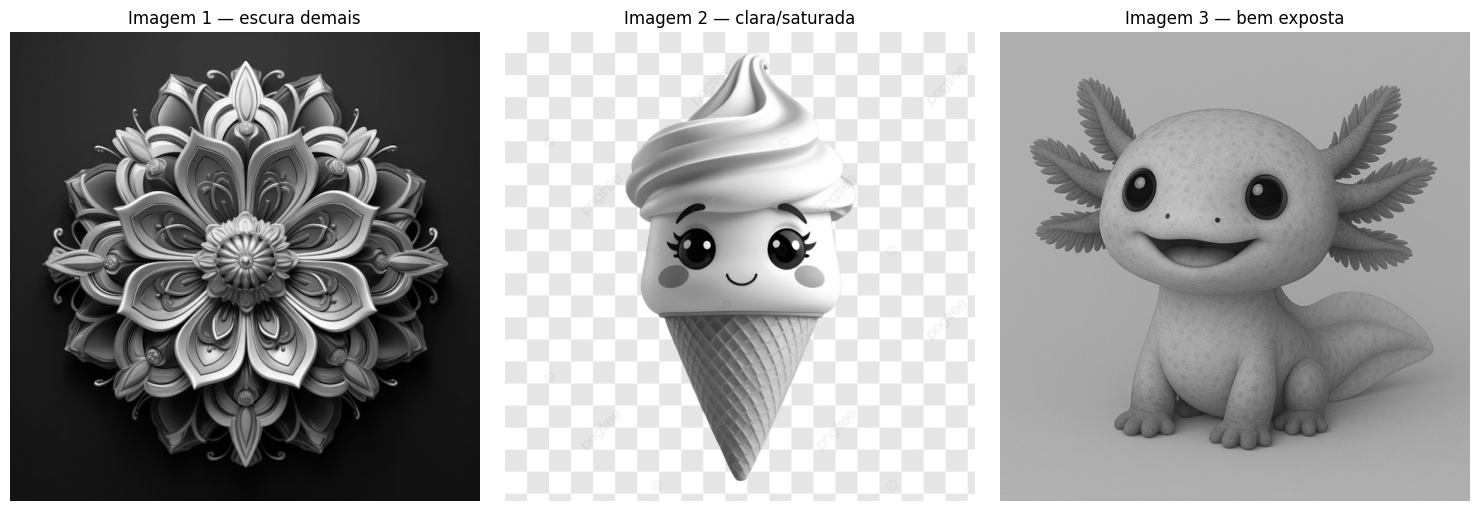

In [7]:
# Endereço da pasta com as imagens no GitHub
url_base = (
    "https://raw.githubusercontent.com/"
    "lianeheidemann/atividades-processamento-de-imagens/"
    "main/atividade/atividade-2/input/"
)

def carregar_imagem(nome_arquivo):
    resposta = requests.get(url_base + nome_arquivo)
    resposta.raise_for_status()
    return Image.open(BytesIO(resposta.content))

# Imagem 1: escura demais / Imagem 2: clara demais ou saturada / Imagem 3: bem exposta
imagem_1 = carregar_imagem("input_1.png")
imagem_2 = carregar_imagem("input_2.png")
imagem_3 = carregar_imagem("input_3.png")

imagem_cinza_1 = np.array(imagem_1.convert("L"), dtype=np.uint8)
imagem_cinza_2 = np.array(imagem_2.convert("L"), dtype=np.uint8)
imagem_cinza_3 = np.array(imagem_3.convert("L"), dtype=np.uint8)

fig, eixos = plt.subplots(1, 3, figsize=(15, 5))
titulos = ["Imagem 1 — escura demais", "Imagem 2 — clara/saturada", "Imagem 3 — bem exposta"]
for eixo, imagem, titulo in zip(eixos, [imagem_cinza_1, imagem_cinza_2, imagem_cinza_3], titulos):
    eixo.imshow(imagem, cmap="gray", vmin=0, vmax=255)
    eixo.set_title(titulo)
    eixo.axis("off")
plt.tight_layout()
plt.show()

## 3. Imagem 1 — escura demais

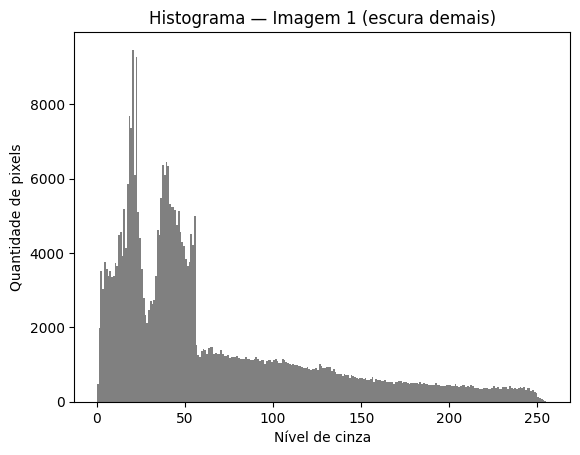

In [8]:
histograma_matplotlib(imagem_cinza_1, "Histograma — Imagem 1 (escura demais)")

**Diagnóstico:** as intensidades estão fortemente concentradas entre 0 e 60
(cerca de 64.7% dos pixels), com média 65.1 e poucos pixels acima de 200
(4.8%). Isso indica uma imagem predominantemente escura, na qual apenas os
detalhes mais claros do centro escapam dessa faixa baixa.

**Operação escolhida:** correção gamma, com **γ = 0,5**. Como a imagem já usa toda a faixa de
intensidades (mínimo 0, máximo 255), a expansão de contraste não teria efeito
(não há o que "esticar"); a correção gamma com γ < 1 clareia proporcionalmente mais os tons baixos
do que os altos, que é exatamente o problema desta imagem.

NameError: name 'matriz_1' is not defined

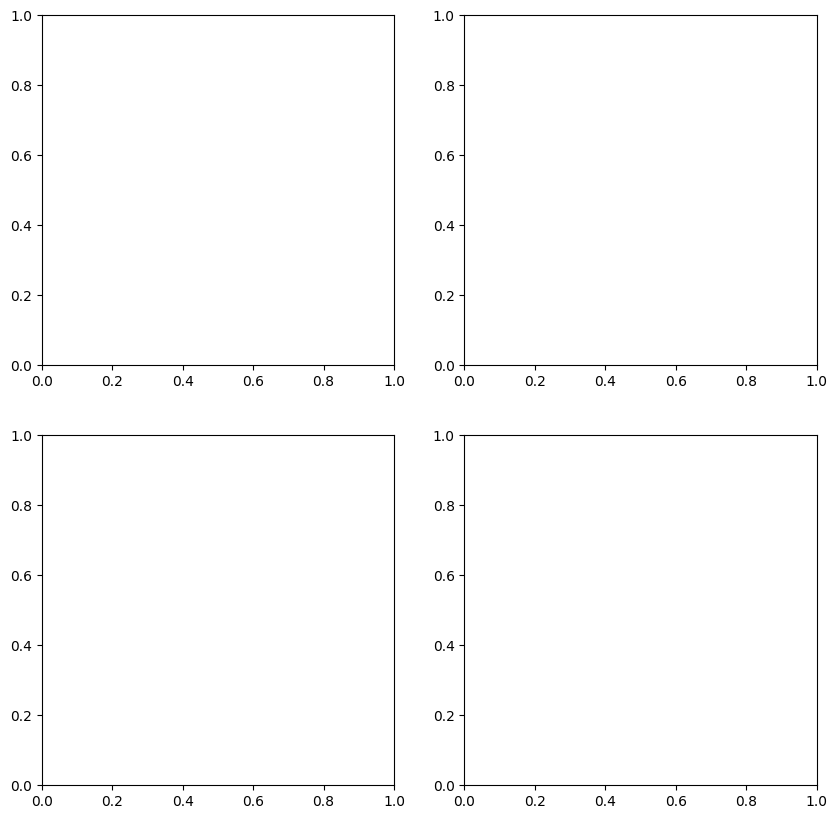

In [9]:
gamma = 0.5
resultado_1 = correcao_gamma_numpy(imagem_cinza_1, gamma)

fig, eixos = plt.subplots(2, 2, figsize=(10, 10))

eixos[0, 0].imshow(matriz_1, cmap="gray", vmin=0, vmax=255)
eixos[0, 0].set_title("Antes")
eixos[0, 0].axis("off")

eixos[0, 1].imshow(resultado_1, cmap="gray", vmin=0, vmax=255)
eixos[0, 1].set_title(f"Depois (correção gamma, γ = {gamma})")
eixos[0, 1].axis("off")

eixos[1, 0].hist(matriz_1.ravel(), bins=256, range=(0, 256), color="gray")
eixos[1, 0].set_title("Histograma antes")
eixos[1, 0].set_xlabel("Intensidade")
eixos[1, 0].set_ylabel("Pixels")

eixos[1, 1].hist(resultado_1.ravel(), bins=256, range=(0, 256), color="steelblue")
eixos[1, 1].set_title("Histograma depois")
eixos[1, 1].set_xlabel("Intensidade")
eixos[1, 1].set_ylabel("Pixels")

plt.tight_layout()
plt.show()

## 4. Imagem 2 — clara demais / saturada

In [ ]:
histograma_matplotlib(imagem_cinza_2, "Histograma — Imagem 2 (clara/saturada)")

**Diagnóstico:** as intensidades se concentram fortemente perto do branco — 82.2%
dos pixels estão acima de 200, com dois picos muito altos (perto de 230 e em 255 — fundo
estourado/saturado). Média 222.4 e apenas 1.2% dos pixels abaixo de 60.
É uma imagem clara demais/saturada, com quase nenhum detalhe nas sombras.

**Operação escolhida:** correção gamma, com **γ = 4**. A equalização de histograma foi testada
primeiro, mas como praticamente toda a imagem já está concentrada em dois picos muito próximos de
255, a CDF fica quase saturada logo no início da faixa e a equalização acaba escurecendo demais
até tons que originalmente eram claros, distorcendo a imagem. Já a expansão de contraste não
ajudaria, pois a imagem já usa toda a faixa (mínimo 0, máximo 255). A
correção gamma com γ > 1 escurece a imagem de forma suave e proporcional, atenuando a saturação
sem gerar esses artefatos.

In [ ]:
gamma_2 = 4
resultado_2 = correcao_gamma_numpy(imagem_cinza_2, gamma_2)

fig, eixos = plt.subplots(2, 2, figsize=(10, 10))

eixos[0, 0].imshow(matriz_2, cmap="gray", vmin=0, vmax=255)
eixos[0, 0].set_title("Antes")
eixos[0, 0].axis("off")

eixos[0, 1].imshow(resultado_2, cmap="gray", vmin=0, vmax=255)
eixos[0, 1].set_title(f"Depois (correção gamma, γ = {gamma_2})")
eixos[0, 1].axis("off")

eixos[1, 0].hist(matriz_2.ravel(), bins=256, range=(0, 256), color="gray")
eixos[1, 0].set_title("Histograma antes")
eixos[1, 0].set_xlabel("Intensidade")
eixos[1, 0].set_ylabel("Pixels")

eixos[1, 1].hist(resultado_2.ravel(), bins=256, range=(0, 256), color="steelblue")
eixos[1, 1].set_title("Histograma depois")
eixos[1, 1].set_xlabel("Intensidade")
eixos[1, 1].set_ylabel("Pixels")

plt.tight_layout()
plt.show()

## 5. Imagem 3 — bem exposta

In [ ]:
histograma_matplotlib(imagem_cinza_3, "Histograma — Imagem 3 (bem exposta)")

**Diagnóstico:** as intensidades se concentram principalmente entre 100 e 200 (média
151.4, desvio 33.2), sem os acúmulos extremos perto de 0 ou 255 vistos nas
imagens anteriores — um histograma unimodal e relativamente compacto, típico de uma imagem
bem exposta.

**Operação escolhida:** expansão de contraste, com **L = 5** e **H = 204**.
Como a imagem já é bem exposta, mas não utiliza toda a faixa de 0 a 255 (o mínimo é
5 e o máximo é 204), a expansão de contraste é a operação mais adequada:
ela estica esse intervalo já estreito para ocupar toda a faixa, sem alterar drasticamente a
aparência da imagem como uma equalização ou uma correção gamma fariam.

In [ ]:
resultado_3 = expansao_contraste_numpy(imagem_cinza_3)

fig, eixos = plt.subplots(2, 2, figsize=(10, 10))

eixos[0, 0].imshow(matriz_3, cmap="gray", vmin=0, vmax=255)
eixos[0, 0].set_title("Antes")
eixos[0, 0].axis("off")

eixos[0, 1].imshow(resultado_3, cmap="gray", vmin=0, vmax=255)
eixos[0, 1].set_title(f"Depois (expansão de contraste, L=5, H=204)")
eixos[0, 1].axis("off")

eixos[1, 0].hist(matriz_3.ravel(), bins=256, range=(0, 256), color="gray")
eixos[1, 0].set_title("Histograma antes")
eixos[1, 0].set_xlabel("Intensidade")
eixos[1, 0].set_ylabel("Pixels")

eixos[1, 1].hist(resultado_3.ravel(), bins=256, range=(0, 256), color="steelblue")
eixos[1, 1].set_title("Histograma depois")
eixos[1, 1].set_xlabel("Intensidade")
eixos[1, 1].set_ylabel("Pixels")

plt.tight_layout()
plt.show()

## 6. Conclusão

A operação que fez **menos diferença** foi a aplicada na **Imagem 3 (bem exposta)**: a diferença
média de intensidade entre antes e depois foi de apenas 35.7 níveis, contra 50.9 na
Imagem 1 e 45.6 na Imagem 2. Isso acontece porque a Imagem 3 já estava bem exposta, com um
histograma concentrado em uma faixa razoavelmente ampla e sem saturação nas extremidades — o
intervalo de intensidades já utilizado (L=5, H=204) cobre boa parte da faixa possível, então a
expansão de contraste precisou "esticar" pouco a imagem para ocupar toda a faixa de 0 a 255. Já as
imagens 1 e 2 tinham problemas de exposição mais graves (excesso de pixels escuros ou muito claros
concentrados em faixas estreitas), então as operações escolhidas para corrigi-las produziram
mudanças bem mais visíveis.